In [1]:
! [ -e /content ] && pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.7 MB/s eta 0:00:00
Mounted at /content/gdrive


In [2]:
from fastbook import *

In [3]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

def is_cat(x): return x[0].isupper()
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:58&lt;00:00]</div>

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 140MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.169865,0.021817,0.006766,00:49


epoch,train_loss,valid_loss,error_rate,time
0,0.048740,0.007893,0.003383,00:45


In [4]:
path = untar_data(URLs.CAMVID_TINY)
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

learn = unet_learner(dls, resnet34)
learn.fine_tune(8)

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:01&lt;00:00]</div>

epoch,train_loss,valid_loss,time
0,3.009270,2.532513,00:02


epoch,train_loss,valid_loss,time
0,1.826546,1.502338,00:03
1,1.568343,1.185080,00:02
2,1.390639,1.137851,00:02
3,1.274998,0.919333,00:02
4,1.144581,0.884023,00:02
5,1.040419,0.770234,00:02
6,0.949533,0.767575,00:01
7,0.879798,0.766407,00:02


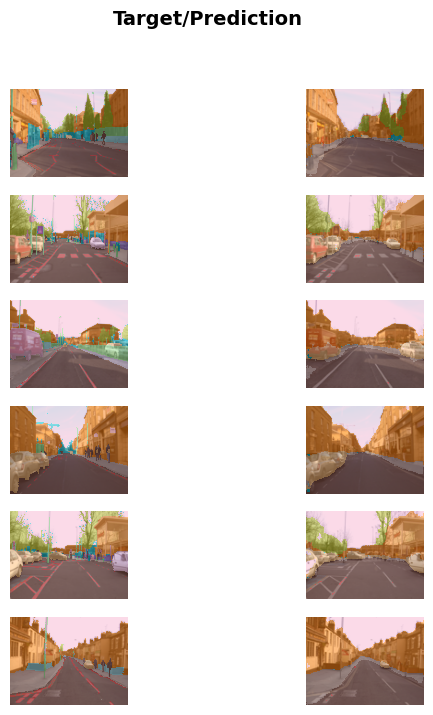

In [5]:
learn.show_results(max_n=6, figsize=(7,8))

In [ ]:
from fastai.text.all import *

dls = TextDataLoaders.from_folder(untar_data(URLs.IMDB), valid='test')
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(4, 1e-2)

<div><progress max="144440600" value="144441344"></progress> 100.00% [144441344/144440600 00:10&lt;00:00]</div>

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:10&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,time
0,0.462876,0.387485,0.828160,03:55


epoch,train_loss,valid_loss,accuracy,time


In [ ]:
learn.predict("I really liked that movie!")

In [ ]:
doc(learn.predict)

In [ ]:
from fastai.tabular.all import *
path = untar_data(URLs.ADULT_SAMPLE)

dls = TabularDataLoaders.from_csv(path/'adult.csv', path=path, y_names="salary",
    cat_names = ['workclass', 'education', 'marital-status', 'occupation',
                 'relationship', 'race'],
    cont_names = ['age', 'fnlwgt', 'education-num'],
    procs = [Categorify, FillMissing, Normalize])

learn = tabular_learner(dls, metrics=accuracy)

In [ ]:
learn.fit_one_cycle(3)

In [ ]:
from fastai.collab import *
path = untar_data(URLs.ML_SAMPLE)
dls = CollabDataLoaders.from_csv(path/'ratings.csv')
learn = collab_learner(dls, y_range=(0.5,5.5))
learn.fine_tune(10)

In [ ]:
learn.show_results()